In [ ]:
#Code 4 (reads in master_df_with_features and runs K-Means Clustering; features based on OEP file focusing on enrollees -- have not integrated additional external files yet like SVI to look at broader community)

# How to run:
# 1) Load libraries and read data from master_df_with_features which should be the output from [2] (Capstone_HL_featureengineering).
#    This file contains features generated from OEP PUF only. Purpose is to run K-means on it and then SVI is appended later, prior to XGBoost.
# 2) final_features_to_cluster lists all of the features that will be used in K-means
# 3) VALIDATION BLOCK checks the data, should be run each time.
# 4) ProfileReport is optional.
# 5) Run standardscaler each time and create "X_scaled"
# 6) Elbow method and Silhouette Score were both created to optimize K-means and cross-validate each other. Can run one, or other or both.
# 7) Additional code block 5C was created to deep dive on Silhouette analysis and includes: appending sample Silhouette scores to each row of df, running feature importance (i.e. top feature drivers), create Silhouette plot
# 8) Set CHOSEN_K
# 9) Run K-means, profiling, and visualization
# 10) Final line: export df.to_excel('output/master_df_with_features_clusters.xlsx', index=False)

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples

from ydata_profiling import ProfileReport

In [10]:
df = pd.read_excel('output/master_df_with_features.xlsx')
df=df.drop(columns=['Unnamed: 0'])
df.info()

random_s = None


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2156 entries, 0 to 2155
Data columns (total 51 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   County FIPS Code                  2156 non-null   int64  
 1   State                             2156 non-null   object 
 2   total_enrollees_master            2156 non-null   int64  
 3   count_age_55_64                   2156 non-null   int64  
 4   count_age_65_plus                 2156 non-null   int64  
 5   count_gt_400_fpl                  2156 non-null   int64  
 6   count_gt_100_150_fpl              2156 non-null   int64  
 7   count_gt_150_200_fpl              2156 non-null   int64  
 8   benchmark_60_401_diff             2156 non-null   float64
 9   count_55_plus                     2156 non-null   int64  
 10  factor_age_55_plus                2156 non-null   float64
 11  V1_lowincome                      2156 non-null   float64
 12  V2_oop

In [ ]:
# Optional code block: the following code excludes the original "Cluster 3" Counties (i.e. treating those as outliers) from original list of 2156 Counties in order to re-run K-means.
#exclusions = pd.read_excel('data/County_Exclusions_Cluster3.xlsx')
#exclusions.info()
#df2 = df[~df['County FIPS Code'].isin(exclusions['County FIPS Code'])]
#df=df2
#df.info()

In [ ]:
## Features to include in K-means (version 1):

#final_features_to_cluster = [
#    # --- PLAN MIX ---
#    'feat_pct_bronze',           
#    'feat_pct_premium_tier',             
    
    # --- COST & VALUE ---
#    'avg_gross_premium',      
#    'feat_pct_paying_under_10',  
    
    # --- MARKET BEHAVIOR ---
#    'feat_net_attrition',        
#    'feat_market_newness',       
#    'feat_passive_renewal',      
    
    # --- DEMOGRAPHICS ---
#    'feat_pct_age_18_34',     
#    'feat_pct_black',            
#    'feat_pct_hispanic',
#    'feat_pct_asian',
#    'feat_pct_aian',             
#    'feat_pct_white'
#]

#Excluded features (these are features that were created in Capstone_HL_featureengineering.ipynb, but excluded in K-means):
#  feat_subsidy_reliance: remove (too circular and close to Risk A definition for cliff risk)
#  feat_pct_silver: Direct input for downgrade risk (# consumers with CSR)
#  feat_pct_female (Lack of computational power. Gender distribution is extremely uniform across US geography. Almost every county is ~50-52% female.)
#  feat_pct_nhpi, feat_pct_multiracial, feat_pct_other_race (In 95% of US counties, these values are near 0%)
#  feat_pct_unknown_hispanic, feat_pct_unknown_race (These represent missing data, not human behaviors.)
#  feat_churn_rate_recent (Avoid collinearity with feat_curn_rate_avg. Feat_curn_rate_avg is more smooth, because it uses 2 years of data, not 1, and is less influenced by recency bias.)

In [16]:
## Features to include in K-means (version 2):

final_features_to_cluster = [
    # --- PLAN MIX ---
    'feat_pct_bronze',                # % bronze enrollees
    'feat_pct_gold',                  # % gold enrollees
    #'plan_value_density',            # %gold enrollees divided by (%gold + %bronze enrollees)

    # --- INCOME LEVEL ---
    'feat_pct_FPL_100_150',         # % enrollees 100-150% FPL
    #'feat_pct_FPL_150_250',         # % enrollees 150-250% FPL
    #'feat_pct_FPL_250_400',         # % enrollees 250-400% FPL
    'feat_pct_FPL_400_plus',       # % enrollees 400%+ FPL

    # --- COST & VALUE ---
    'avg_premium_before_APTC',          # avg premium before APTC in dollars
    'feat_subsidy_coverage_ratio',      # (avg premium (before) - avg premium (after))/avg premium (before)
    
    # --- MARKET BEHAVIOR ---
    'feat_net_attrition',               # net attrition
    'feat_market_newness',              # % of new enrollees
    'feat_passive_renewal',             # % of enrollees with automatic/passive renewal
    
    # --- DEMOGRAPHICS ---
    #'feat_pct_age_18_34',              # % of enrollees 18-34
    'feat_pct_age_55_over',             # % of enrollees 55+yo
    'feat_pct_black',                   # % of enrollees who are African American
    'feat_pct_hispanic',                # % of enrollees who are Hispanic
    'feat_pct_asian',                   # % of enrollees who are Asian
    'feat_pct_aian',                    # % of enrollees who are American Indian/Alaska Native
    #'feat_pct_white'                   # % of enrollees who are White; exclude from clustering but then include when evaluating clusters
]

In [4]:
# VALIDATION BLOCK
# Verify columns exist
missing_cols = [c for c in final_features_to_cluster if c not in df.columns]
if missing_cols:
    print(f"⚠️ Missing columns in dataframe: {missing_cols}")
    # Remove missing to allow script to run partially
    final_features_to_cluster = [c for c in final_features_to_cluster if c in df.columns]

X = df[final_features_to_cluster]

# Data Validation (ensure no NaNs)
if X.isnull().values.any():
    print("\n" + "="*60)
    print("🛑 CRITICAL ERROR: MISSING VALUES FOUND")
    print("="*60)
    print("The following columns still contain NaNs:")
    print("-" * 30)
    print(X.isnull().sum()[X.isnull().sum() > 0])
    print("-" * 30)
    raise ValueError("Data Validation Failed: Input data is not clean. Please fix NaNs in the source file before clustering.")
else:
    print("\n✅ Data Quality Check Passed: No missing values found.")

# Target Variable Y Data Leakage Check
target_col = 'Access_Disruption_Risk_Index'

if target_col in df.columns:
    print(f"\n--- 🔍 Checking for Circular Logic / Leakage ---")
    correlations = X.corrwith(df[target_col]).abs().sort_values(ascending=False)
    
    print(correlations.head(10))
    
    leaking_features = correlations[correlations > 0.65].index.tolist()
    if leaking_features:
        print(f"\n⚠️ WARNING: The following features are highly correlated (>0.65) with Risk Index:")
        for f in leaking_features:
            print(f"   - {f}")
        print("   Consider removing these if you want clusters independent of risk level.")
    else:
        print("\n✅ Features look 'safe' (no massive correlation with Risk Index).")


✅ Data Quality Check Passed: No missing values found.

--- 🔍 Checking for Circular Logic / Leakage ---
feat_net_attrition             0.508329
feat_passive_renewal           0.418442
feat_pct_FPL_100_150           0.314120
feat_pct_aian                  0.245434
feat_subsidy_coverage_ratio    0.202601
feat_market_newness            0.202495
feat_pct_FPL_250_400           0.188542
feat_pct_age_55_over           0.186980
feat_pct_black                 0.105012
avg_premium_before_APTC        0.090061
dtype: float64

✅ Features look 'safe' (no massive correlation with Risk Index).


In [7]:
# OPTIONAL: Run Profile Report on X
profile = ProfileReport(X, title="Profiling Report")
profile.to_file("X_ProfileReport.html")

# Display in ipynb
#profile.to_notebook_iframe()


C:\Users\liuh102\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\ydata_profiling\utils\dataframe.py:137: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns={"index": "df_index"}, inplace=True)


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 16/16 [00:00<00:00, 3198.71it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [5]:
# Scale the data (StandardScaler)
# Critical because 'subsidy_reliance' is 0-1 (or 0-100 if you fixed it) and others are 0-100
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)


🤖 Auto-Detected Optimal K: 3


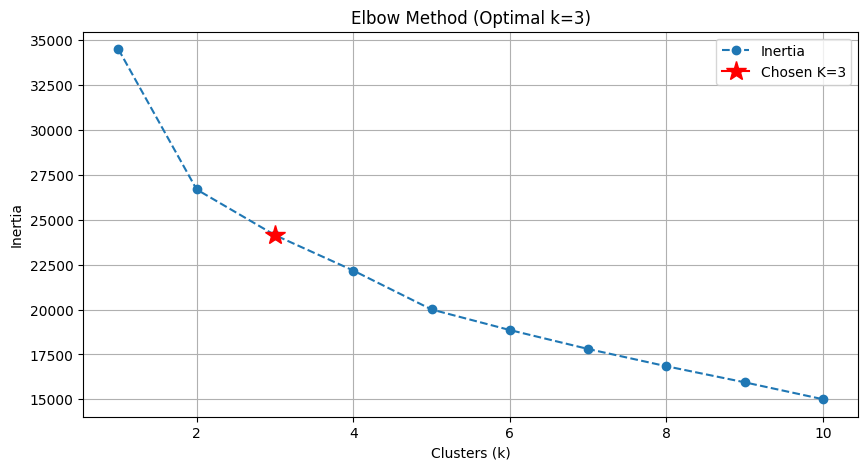

In [17]:
# ---------------------------------------------------------
# 5. Determine Optimal K (Elbow)
# ---------------------------------------------------------
inertia = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=random_s, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

def find_optimal_k(K_range, inertia):
    """
    Finds the elbow point using the 'Maximum Distance from Line' method.
    Draws a line from first to last point. The point furthest from this line
    is chosen as the elbow.
    """
    x1, y1 = K_range[0], inertia[0]
    x2, y2 = K_range[-1], inertia[-1]

    distances = []
    for i, k in enumerate(K_range):
        x0 = k
        y0 = inertia[i]
        
        # Perpendicular distance formula from point (x0, y0) to line defined by (x1, y1) and (x2, y2)
        numerator = abs((y2 - y1) * x0 - (x2 - x1) * y0 + x2 * y1 - y2 * x1)
        denominator = np.sqrt((y2 - y1)**2 + (x2 - x1)**2)
        distances.append(numerator / denominator)
    
    best_index = np.argmax(distances)
    return K_range[best_index]

CHOSEN_K = find_optimal_k(list(K_range), inertia)
print(f"\n🤖 Auto-Detected Optimal K: {CHOSEN_K}")

# Plotting the result
plt.figure(figsize=(10, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--', label='Inertia')
plt.plot(CHOSEN_K, inertia[CHOSEN_K-1], marker='*', color='red', markersize=15, label=f'Chosen K={CHOSEN_K}')
plt.title(f'Elbow Method (Optimal k={CHOSEN_K})')
plt.xlabel('Clusters (k)')
plt.ylabel('Inertia')
plt.legend()
plt.grid(True)
plt.show()


--- 📊 Running Silhouette Score Validation ---
ℹ️ Best K by Silhouette Score: 2
   (Score: 0.2340)
⚠️ Note: Silhouette (2) disagrees with Elbow (3).
   This is common. Elbow favors the 'turn', Silhouette favors separation.
   Proceeding with Elbow K for now, but inspect the profiles.


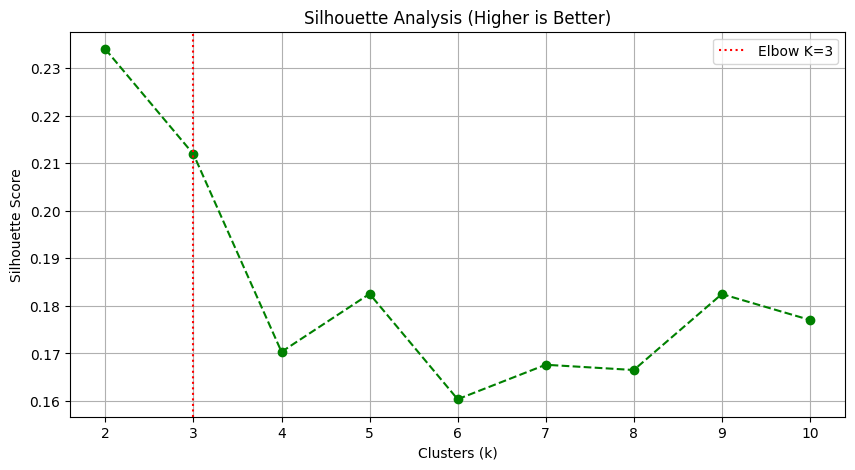

In [18]:
# ---------------------------------------------------------
# 5b. Silhouette Score Validation (Parallel Run)
# ---------------------------------------------------------
print("\n--- 📊 Running Silhouette Score Validation ---")
silhouette_scores = []
# Silhouette requires at least 2 clusters
K_range_sil = range(2, 11) 

for k in K_range_sil:
    kmeans_sil = KMeans(n_clusters=k, random_state=random_s, n_init=10)
    labels_sil = kmeans_sil.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels_sil)
    silhouette_scores.append(score)

best_sil_k = K_range_sil[np.argmax(silhouette_scores)]
print(f"ℹ️ Best K by Silhouette Score: {best_sil_k}")
print(f"   (Score: {max(silhouette_scores):.4f})")
if best_sil_k != CHOSEN_K:
    print(f"⚠️ Note: Silhouette ({best_sil_k}) disagrees with Elbow ({CHOSEN_K}).")
    print("   This is common. Elbow favors the 'turn', Silhouette favors separation.")
    print("   Proceeding with Elbow K for now, but inspect the profiles.")

plt.figure(figsize=(10, 5))
plt.plot(K_range_sil, silhouette_scores, marker='o', linestyle='--', color='green')
plt.axvline(x=CHOSEN_K, color='red', linestyle=':', label=f'Elbow K={CHOSEN_K}')
plt.title('Silhouette Analysis (Higher is Better)')
plt.xlabel('Clusters (k)')
plt.ylabel('Silhouette Score')
plt.legend()
plt.grid(True)
plt.show()


--- Cluster Profiles (k=3) ---
Cluster                            0       1       2
feat_pct_bronze                34.01   44.88    9.33
feat_pct_gold                   5.13   12.69   38.81
feat_pct_FPL_100_150           53.69   20.91   58.03
feat_pct_FPL_400_plus           4.01   13.05    3.08
avg_premium_before_APTC       675.49  756.10  678.14
feat_subsidy_coverage_ratio     0.88    0.79    0.91
feat_net_attrition              3.06    9.51    5.84
feat_market_newness            15.11   15.80   15.42
feat_passive_renewal           56.75   36.98   46.01
feat_pct_age_55_over           25.95   31.32   23.19
feat_pct_black                  4.44    0.45    2.16
feat_pct_hispanic               2.17    1.93   14.62
feat_pct_asian                  1.18    1.18    1.50
feat_pct_aian                   0.86    1.35    0.14
Access_Disruption_Risk_Index   56.07   51.73   54.66
Count                         979.00  906.00  271.00
% of Data                      45.41   42.02   12.57

--- B. Weight

C:\Users\liuh102\AppData\Local\Temp\ipykernel_12372\2436049485.py:43: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weighted_profile = df.groupby('Cluster').apply(


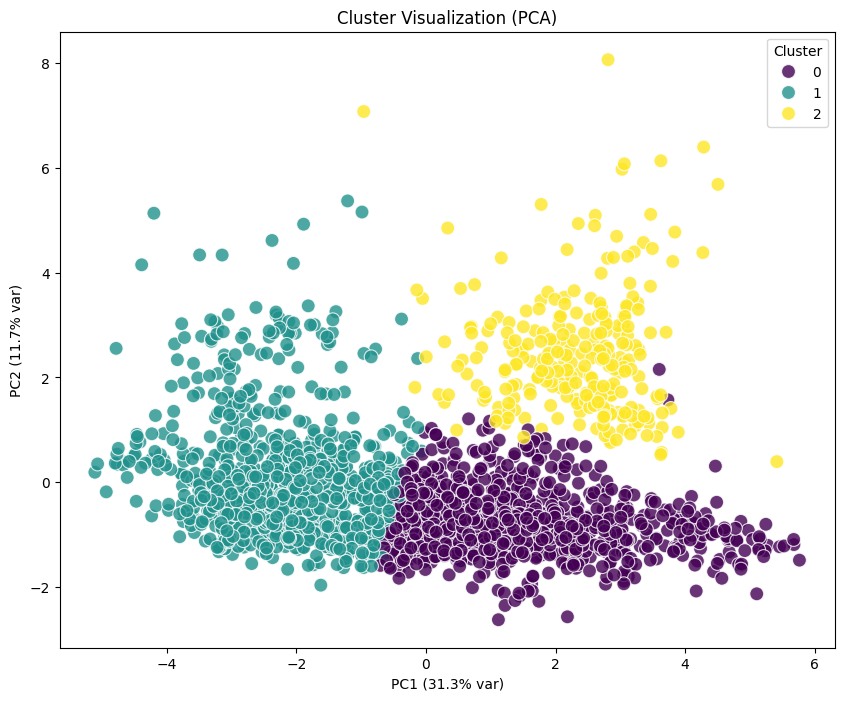

In [19]:
CHOSEN_K = 3

# ---------------------------------------------------------
# 6. Run Clustering
# ---------------------------------------------------------
kmeans = KMeans(n_clusters=CHOSEN_K, random_state=random_s, n_init=50)
cluster_labels = kmeans.fit_predict(X_scaled)
df['Cluster'] = cluster_labels

# ---------------------------------------------------------
# 7. Profiling (Interpretation)
# ---------------------------------------------------------
# Profile based on Clustering Features AND the Risk Index
profile_cols = final_features_to_cluster + [target_col]
profile_cols = [c for c in profile_cols if c in df.columns]

# Unweighted profile
# Every data point (county) is treated as equal by K-means algorithm i.e. a tiny county with 10 people and a huge county with 100,000 people.
# The unweighted average describes the center of the "dot cloud" that the algorithm found. E.g. "the typical market in Cluster 2 has an $882 premium."
# Use when designing operational strategies (e.g., "We need a sales strategy for 500 small rural counties").
cluster_profile = df.groupby('Cluster')[profile_cols].mean()
cluster_profile['Count'] = df['Cluster'].value_counts()
cluster_profile['% of Data'] = (cluster_profile['Count'] / len(df)) * 100

print(f"\n--- Cluster Profiles (k={CHOSEN_K}) ---")
print(cluster_profile.T.round(2))


# Population-weighted profile calculated using total enrollees
weight_col = 'total_enrollees_master'
if weight_col and weight_col in df.columns:
    
    def weighted_avg(x, cols, w_name):
        try:
            return pd.Series(np.average(x[cols], weights=x[w_name], axis=0), index=cols)
        except ZeroDivisionError:
            return pd.Series([0]*len(cols), index=cols)

    # Filter strictly to numeric columns in profile_cols for the math
    numeric_profile_cols = df[profile_cols].select_dtypes(include=[np.number]).columns.tolist()
    
    # Calculate weighted stats per cluster
    weighted_profile = df.groupby('Cluster').apply(
        lambda x: weighted_avg(x, numeric_profile_cols, weight_col)
    )
    
    # Add count context (Counts are still just "number of counties")
    weighted_profile['Count_Counties'] = df['Cluster'].value_counts()
    weighted_profile['Total_Enrollees'] = df.groupby('Cluster')[weight_col].sum()
    weighted_profile['% of Enrollees'] = (weighted_profile['Total_Enrollees'] / df[weight_col].sum()) * 100
    
    print(f"\n--- B. Weighted Cluster Profiles (Enrollee/Impact View) ---")
    print(f"(Weighted by: {weight_col})")
    print(weighted_profile.T.round(2))

# ---------------------------------------------------------
# 8. Visualization
# ---------------------------------------------------------
pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(coords, columns=['PC1', 'PC2'])
pca_df['Cluster'] = df['Cluster']

plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=pca_df, palette='viridis', s=100, alpha=0.8)
plt.title('Cluster Visualization (PCA)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
plt.show()

Overall Average Silhouette Score: 0.2120
(Scores range from -1 to 1. Higher is better.)

--- Cluster Stability (Avg Silhouette Score) ---
Cluster
0    0.275607
2    0.195653
1    0.148123
Name: Silhouette_Score, dtype: float64

Interpretation:
 - High Score (>0.5): Dense, well-separated cluster.
 - Low Score (<0.2): Loose, overlapping cluster (possibly fuzzy definition).

--- Feature Correlation with Silhouette Score (Primary Drivers) ---
feat_passive_renewal           0.284966
feat_pct_FPL_100_150           0.271172
feat_subsidy_coverage_ratio    0.225879
feat_pct_black                 0.107028
feat_pct_bronze                0.022002
feat_pct_hispanic              0.020902
feat_pct_age_55_over          -0.042950
feat_pct_asian                -0.088514
feat_market_newness           -0.088727
feat_pct_gold                 -0.100053
dtype: float64
...(bottom drivers)...
feat_pct_bronze            0.022002
feat_pct_hispanic          0.020902
feat_pct_age_55_over      -0.042950
feat_pct_as

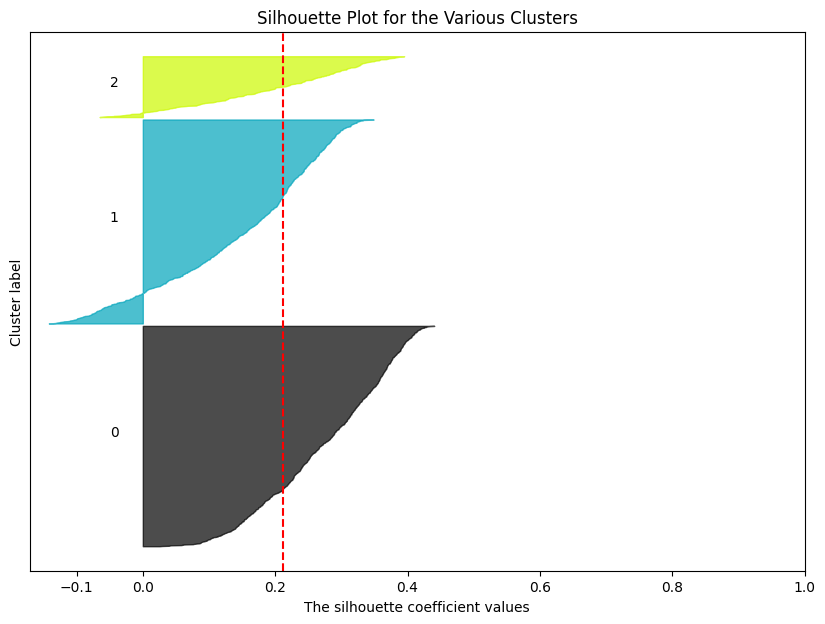

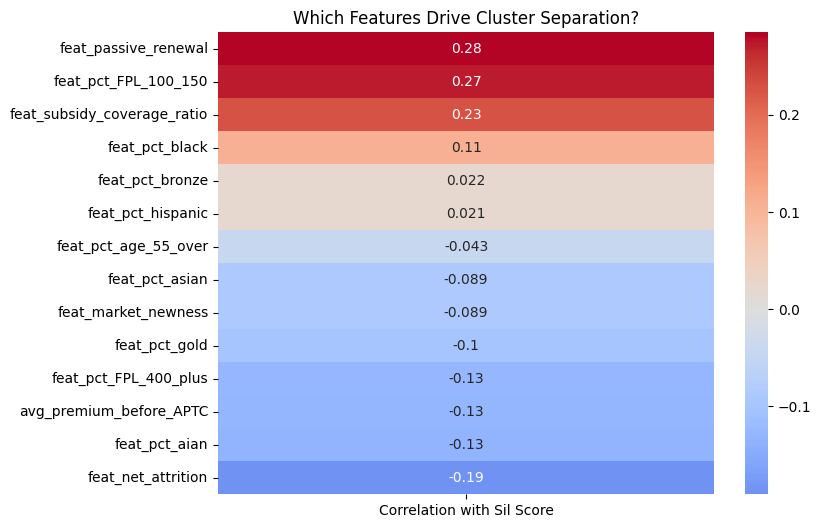

In [20]:
# ---------------------------------------------------------
# 5c. Detailed Silhouette Analysis (NEW SECTION)
# ---------------------------------------------------------

# 1. Calculate Sample Scores
sample_silhouette_values = silhouette_samples(X_scaled, cluster_labels)
overall_silhouette_avg = silhouette_score(X_scaled, cluster_labels)
df['Silhouette_Score'] = sample_silhouette_values

print(f"Overall Average Silhouette Score: {overall_silhouette_avg:.4f}")
print("(Scores range from -1 to 1. Higher is better.)")

# 2. Cluster Stability (Average Score per Cluster)
print("\n--- Cluster Stability (Avg Silhouette Score) ---")
cluster_sil_means = df.groupby('Cluster')['Silhouette_Score'].mean().sort_values(ascending=False)
print(cluster_sil_means)
print("\nInterpretation:")
print(" - High Score (>0.5): Dense, well-separated cluster.")
print(" - Low Score (<0.2): Loose, overlapping cluster (possibly fuzzy definition).")

# 3. Feature Drivers (Correlation with Silhouette)
# Which features drive the 'goodness' of the clustering?
print("\n--- Feature Correlation with Silhouette Score (Primary Drivers) ---")
sil_correlations = df[final_features_to_cluster].corrwith(df['Silhouette_Score']).sort_values(ascending=False)
print(sil_correlations.head(10))
print("...(bottom drivers)...")
print(sil_correlations.tail(10))

# 4. Generate Silhouette Plot
plt.figure(figsize=(10, 7))
y_lower = 10
for i in range(CHOSEN_K):
    # Aggregate the silhouette scores for samples belonging to cluster i, and sort them
    ith_cluster_sil_values = sample_silhouette_values[cluster_labels == i]
    ith_cluster_sil_values.sort()

    size_cluster_i = ith_cluster_sil_values.shape[0]
    y_upper = y_lower + size_cluster_i

    color = cm.nipy_spectral(float(i) / CHOSEN_K)
    plt.fill_betweenx(np.arange(y_lower, y_upper),
                      0, ith_cluster_sil_values,
                      facecolor=color, edgecolor=color, alpha=0.7)

    # Label the silhouette plots with their cluster numbers at the middle
    plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

    # Compute the new y_lower for next plot
    y_lower = y_upper + 10  # 10 for the 0 samples

plt.title("Silhouette Plot for the Various Clusters")
plt.xlabel("The silhouette coefficient values")
plt.ylabel("Cluster label")

# The vertical line for average silhouette score of all the values
plt.axvline(x=overall_silhouette_avg, color="red", linestyle="--")
plt.yticks([])  # Clear the yaxis labels / ticks
plt.xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
plt.show()

# ---------------------------------------------------------
# 7c. Feature Driver Heatmap (Correlation)
# ---------------------------------------------------------
# Visualizing which features correlate with 'being well clustered'
plt.figure(figsize=(8, 6))
sns.heatmap(sil_correlations.to_frame(name='Correlation with Sil Score'), 
            annot=True, cmap='coolwarm', center=0)
plt.title('Which Features Drive Cluster Separation?')
plt.show()

In [15]:
df.to_excel('output/master_df_with_features_clusters.xlsx', index=False)
#df.to_excel('output/master_df_with_features_clusters_v2_(exclude cluster3).xlsx', index=False)